In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [2]:
tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc_hertzsprung.vot")

In [3]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

# Distance
dist_pc = r_from_plx(np.array(tab["parallax"])) # in pc
z_pc = dist_pc * np.sin(np.array(tab["b"])*deg2rad) +14.5 #correction for height of the sun above the galactic plane
# Absolute magnitude
apparent_magnitude = np.array(tab["phot_g_mean_mag"])
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5

teff = np.array(tab["teff_gspphot"]) # in K


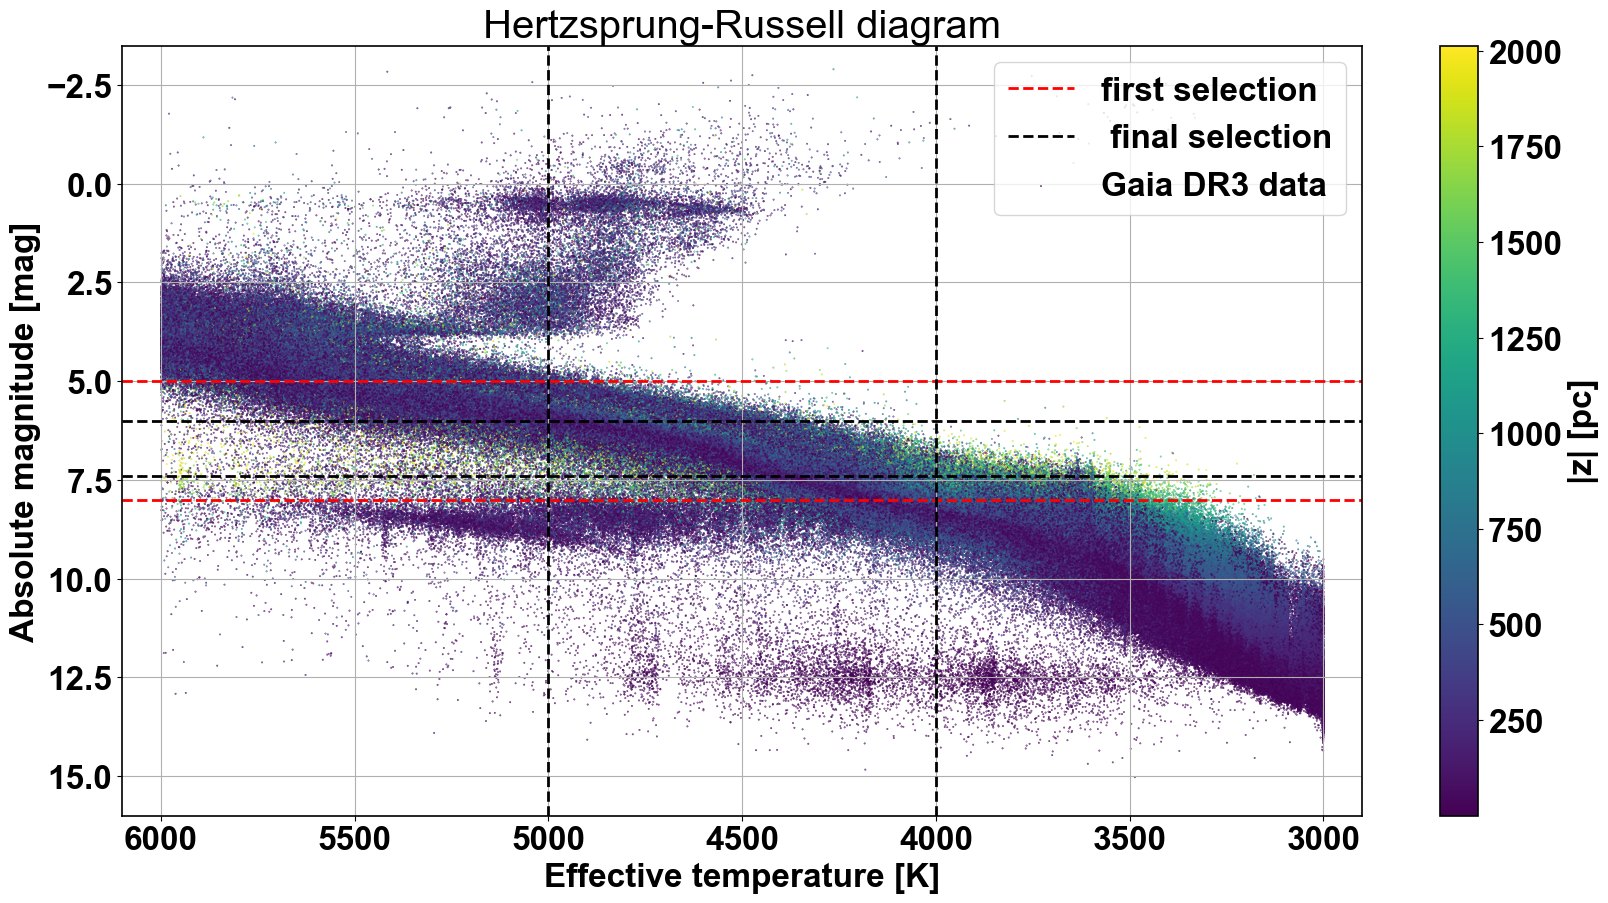

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
ax[0].axvline(x=4000, color='black', linestyle='--', linewidth=2)
ax[0].axvline(x=5000, color='black', linestyle='--', linewidth=2)
# ax[0].fill_between([4000, 5000], 6, 7.4, color='black', alpha=0.7, label=' final selection')
# ax[0].fill_between([4000, 5000], 5, 6, color='r', alpha=0.7, label='first selection')
# ax[0].fill_between([4000, 5000], 7.4, 8, color='r', alpha=0.7)
scatter = ax[0].scatter(teff, absolute_magnitude, c=np.abs(z_pc), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('Effective temperature [K]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
ax[0].invert_xaxis()
ax[0].set_xlim(6100, 2900)
ax[0].set_ylim(16, -3.5)
# ax[0].set_xscale('log')
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
#fig.tight_layout()
plt.savefig('../Plots/hr_full.png')
plt.show()

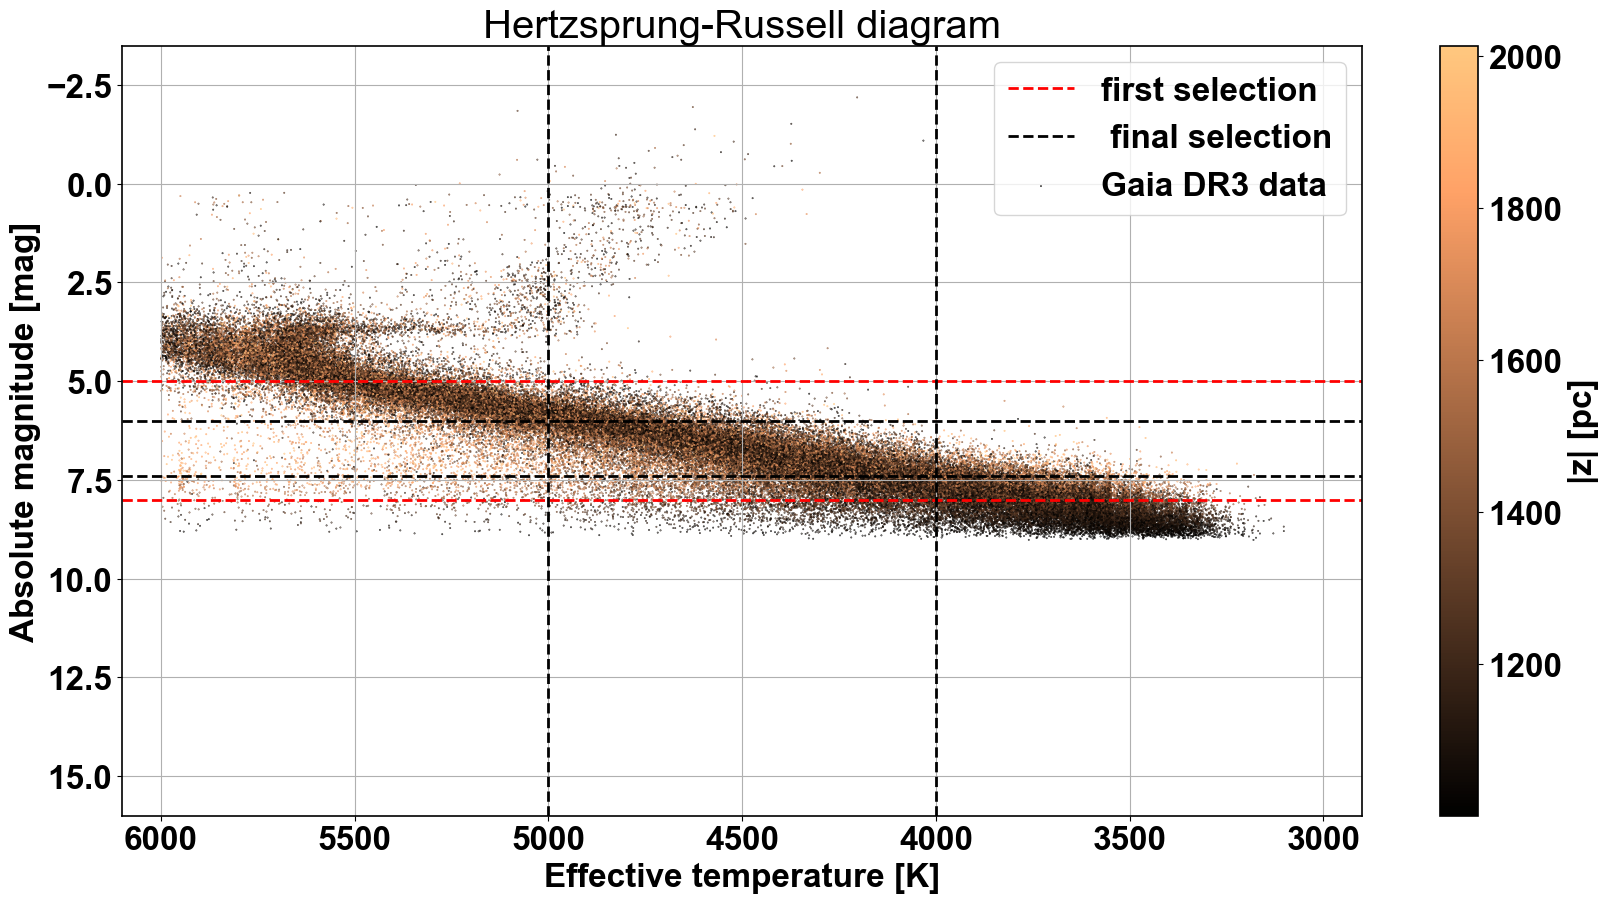

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
ax[0].axvline(x=4000, color='black', linestyle='--', linewidth=2)
ax[0].axvline(x=5000, color='black', linestyle='--', linewidth=2)
# ax[0].fill_between([4000, 5000], 6, 7.4, color='black', alpha=0.7, label=' final selection')
# ax[0].fill_between([4000, 5000], 5, 6, color='r', alpha=0.7, label='first selection')
# ax[0].fill_between([4000, 5000], 7.4, 8, color='r', alpha=0.7)
where = np.where(abs(z_pc)>1000)
scatter = ax[0].scatter(teff[where], absolute_magnitude[where], c=np.abs(z_pc[where]), marker='.', s=0.5, label='Gaia DR3 data', cmap='copper')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('Effective temperature [K]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
ax[0].invert_xaxis()
ax[0].set_xlim(6100, 2900)
ax[0].set_ylim(16, -3.5)
# ax[0].set_xscale('log')
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('../Plots/hr_high.png')
#fig.tight_layout()
plt.show()

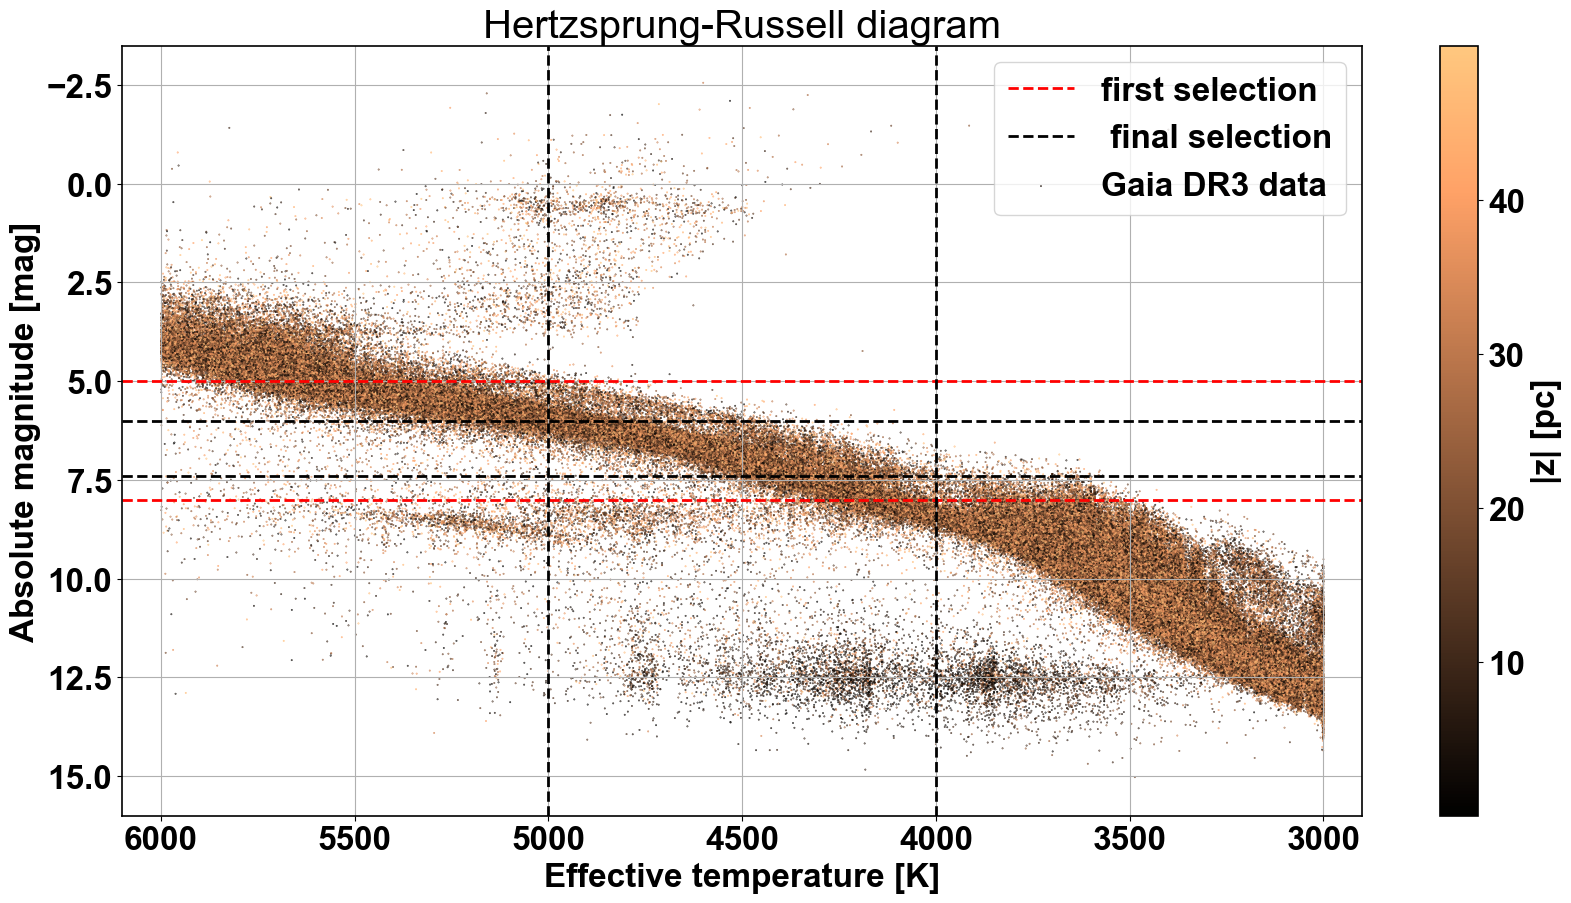

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
ax[0].axvline(x=4000, color='black', linestyle='--', linewidth=2)
ax[0].axvline(x=5000, color='black', linestyle='--', linewidth=2)
# ax[0].fill_between([4000, 5000], 6, 7.4, color='black', alpha=0.7, label=' final selection')
# ax[0].fill_between([4000, 5000], 5, 6, color='r', alpha=0.7, label='first selection')
# ax[0].fill_between([4000, 5000], 7.4, 8, color='r', alpha=0.7)
where = np.where(abs(z_pc)<50)
scatter = ax[0].scatter(teff[where], absolute_magnitude[where], c=np.abs(z_pc[where]), marker='.', s=0.5, label='Gaia DR3 data', cmap='copper')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('Effective temperature [K]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram')
ax[0].invert_yaxis()
ax[0].invert_xaxis()
ax[0].set_xlim(6100, 2900)
ax[0].set_ylim(16, -3.5)
# ax[0].set_xscale('log')
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.savefig('../Plots/hr_low.png')
#fig.tight_layout()
plt.show()

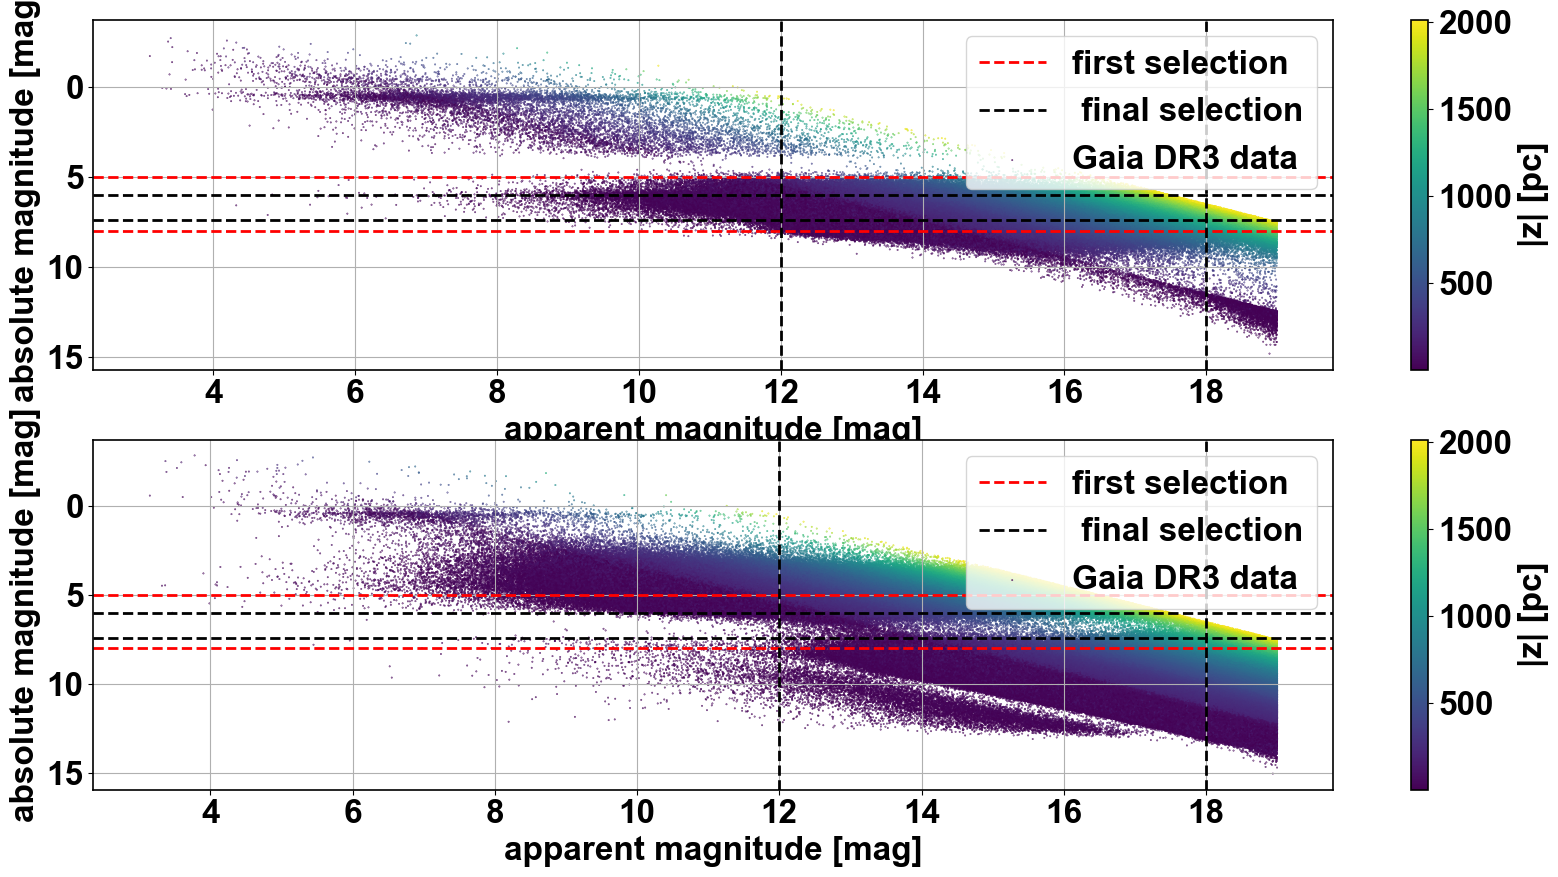

In [7]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
ax[0].axvline(x=18, color='black', linestyle='--', linewidth=2)
ax[0].axvline(x=12, color='black', linestyle='--', linewidth=2)
where = np.where((teff>4000) & (teff<5000))
scatter = ax[0].scatter(apparent_magnitude[where], absolute_magnitude[where], c=np.abs(z_pc[where]), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('apparent magnitude [mag]')
ax[0].set_ylabel('absolute magnitude [mag]')
ax[0].invert_yaxis()
colorbar = fig.colorbar(scatter, ax=ax[0], label='|z| [pc]')

ax[1].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[1].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[1].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[1].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
ax[1].axvline(x=18, color='black', linestyle='--', linewidth=2)
ax[1].axvline(x=12, color='black', linestyle='--', linewidth=2)
where2 = np.where((teff<=4000) | (teff>=5000))
scatter2 = ax[1].scatter(apparent_magnitude[where2], absolute_magnitude[where2], c=np.abs(z_pc[where2]), marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[1].grid()
ax[1].legend(loc='upper right')

ax[1].set_xlabel('apparent magnitude [mag]')
ax[1].set_ylabel('absolute magnitude [mag]')
ax[1].invert_yaxis()
colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='|z| [pc]')

#fig.tight_layout()
plt.show()

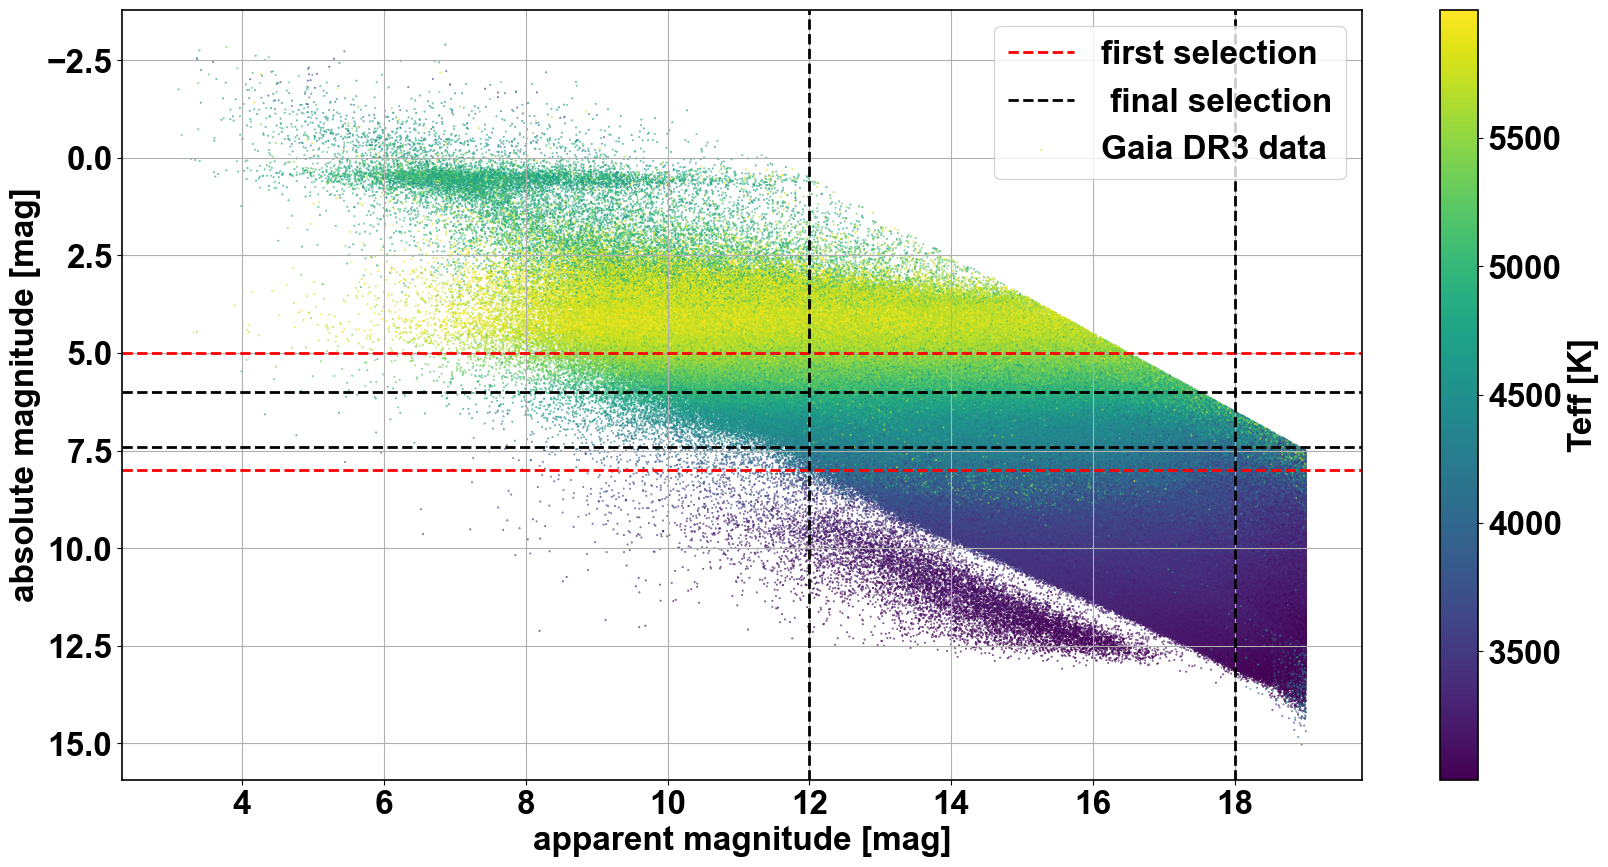

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=5, color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].axhline(y=8, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=6, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=7.4, color='black', linestyle='--', linewidth=2, label=' final selection')
ax[0].axvline(x=18, color='black', linestyle='--', linewidth=2)
ax[0].axvline(x=12, color='black', linestyle='--', linewidth=2)
scatter = ax[0].scatter(apparent_magnitude, absolute_magnitude, c=teff, marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('apparent magnitude [mag]')
ax[0].set_ylabel('absolute magnitude [mag]')
ax[0].invert_yaxis()
colorbar = fig.colorbar(scatter, ax=ax[0], label='Teff [K]')

#fig.tight_layout()
plt.show()

C:\Users\Ruben\AppData\Local\Temp\ipykernel_45884\1291256751.py:9: RuntimeWarning: divide by zero encountered in log10
  m = M + 5.*np.log10(d) - 5.


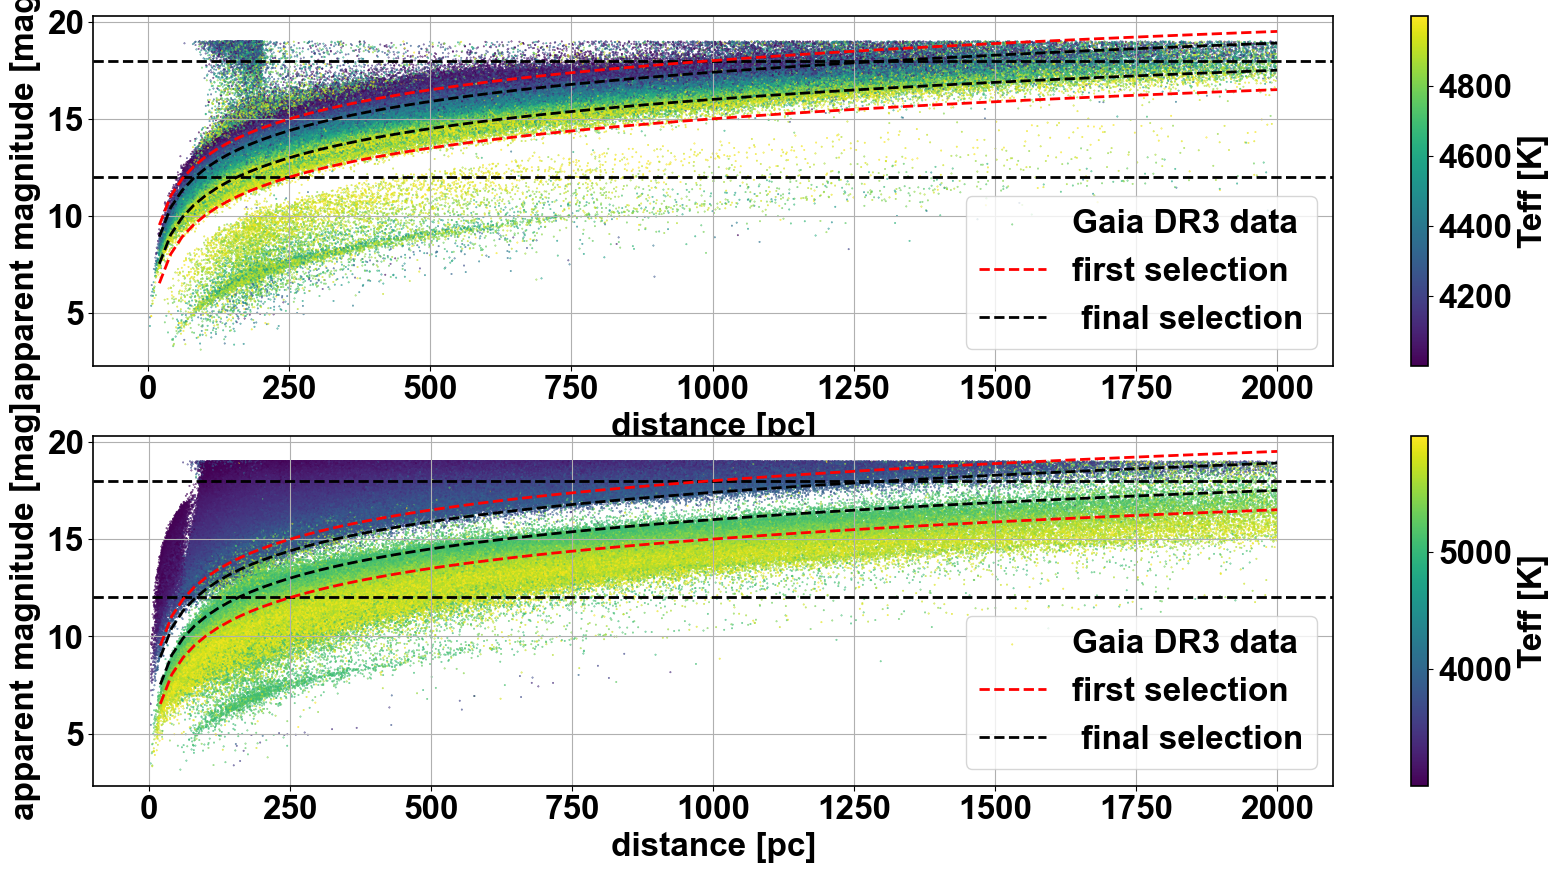

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))
ax[0].axhline(y=18, color='black', linestyle='--', linewidth=2)
ax[0].axhline(y=12, color='black', linestyle='--', linewidth=2)
where = np.where((teff>4000) & (teff<5000))
scatter = ax[0].scatter(np.abs(dist_pc[where]), apparent_magnitude[where], c=teff[where], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')
z = np.linspace(0, 2000, 100)
ax[0].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[0].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[0].plot(z, M_d_to_m(7.4, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[0].grid()
ax[0].legend(loc='lower right')

ax[0].set_ylabel('apparent magnitude [mag]')
ax[0].set_xlabel('distance [pc]')
colorbar = fig.colorbar(scatter, ax=ax[0], label='Teff [K]')

ax[1].axhline(y=18, color='black', linestyle='--', linewidth=2)
ax[1].axhline(y=12, color='black', linestyle='--', linewidth=2)
where2 = np.where((teff<=4000) | (teff>=5000))
scatter2 = ax[1].scatter(np.abs(dist_pc[where2]), apparent_magnitude[where2], c=teff[where2], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')
z = np.linspace(0, 2000, 100)
ax[1].plot(z, M_d_to_m(5, z), color='r', linestyle='--', linewidth=2, label='first selection')
ax[1].plot(z, M_d_to_m(8, z), color='r', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(6, z), color='black', linestyle='--', linewidth=2)
ax[1].plot(z, M_d_to_m(7.4, z), color='black', linestyle='--', linewidth=2, label=' final selection')

ax[1].grid()
ax[1].legend(loc='lower right')

ax[1].set_ylabel('apparent magnitude [mag]')
ax[1].set_xlabel('distance [pc]')
colorbar2 = fig.colorbar(scatter2, ax=ax[1], label='Teff [K]')
plt.savefig('../Plots/hr_distance_vs_apparent_magnitude.png')
#fig.tight_layout()
plt.show()

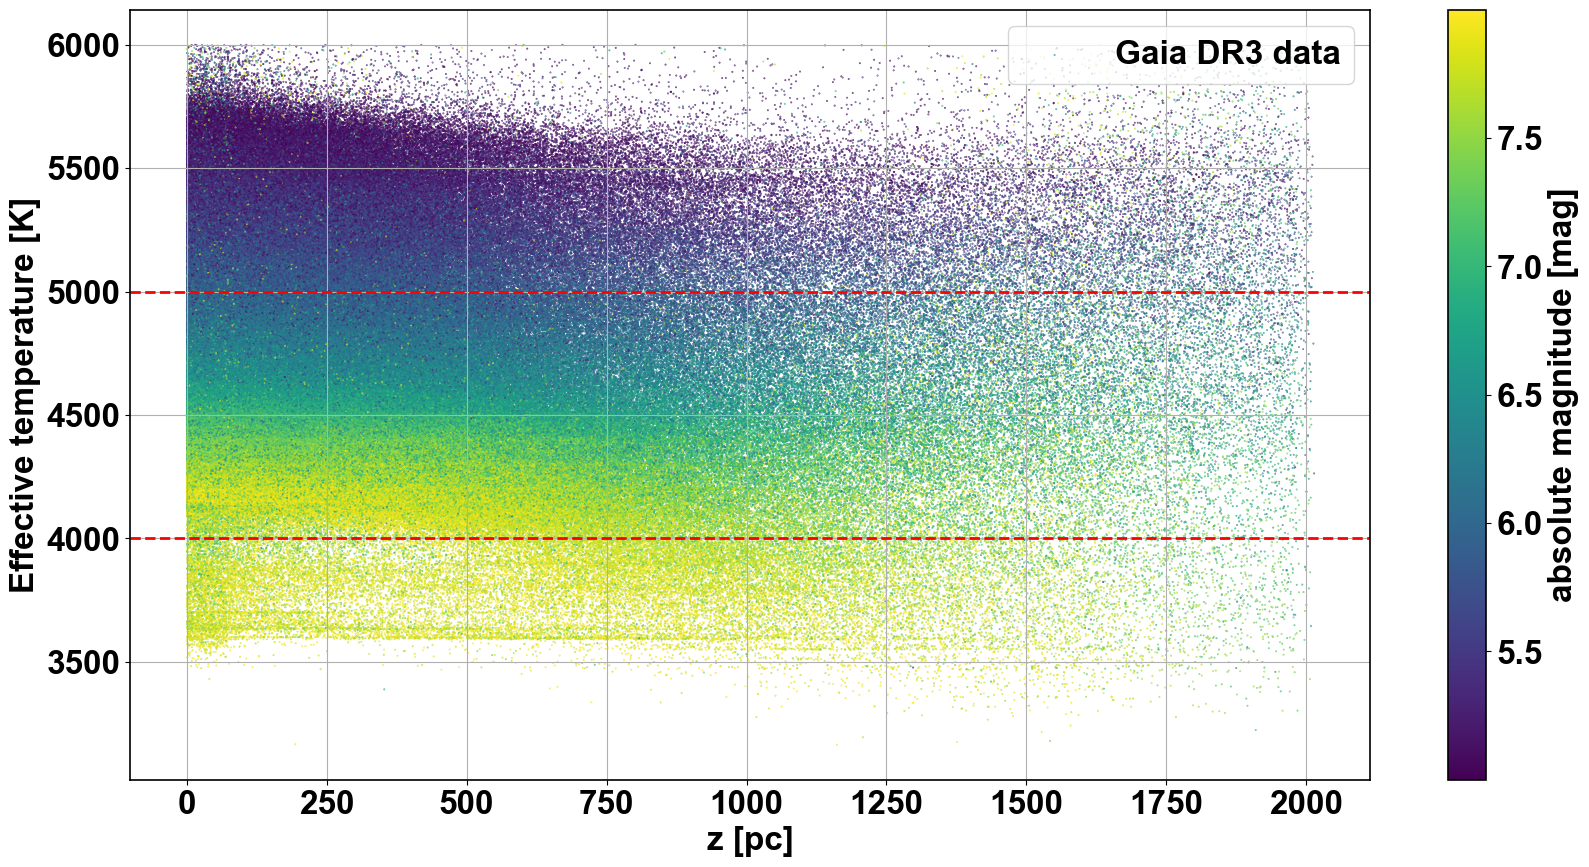

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]
ax[0].axhline(y=4000, color='r', linestyle='--', linewidth=2)
ax[0].axhline(y=5000, color='r', linestyle='--', linewidth=2)
where = np.where((absolute_magnitude>5) & (absolute_magnitude<8))
scatter = ax[0].scatter(np.abs(z_pc[where]), teff[where], c=absolute_magnitude[where], marker='.', s=0.5, label='Gaia DR3 data', cmap='viridis')

ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('z [pc]')
ax[0].set_ylabel('Effective temperature [K]')
colorbar = fig.colorbar(scatter, ax=ax[0], label='absolute magnitude [mag]')

#fig.tight_layout()
plt.show()